In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

Mounted at /content/drive


In [ ]:
import pandas as pd

# ATTACK DATASET
path = "/content/drive/MyDrive/Riset/Review/217_attack_vector.csv"

# Scopus CSV
df = pd.read_csv(path, sep=",", encoding="utf-8")

print("Jumlah baris:", len(df))
print("Kolom:", list(df.columns))

# 3 baris paling awal
print("\n=== 3 Data Paling Awal ===")
print(df.head(3))

# 3 baris paling akhir
print("\n=== 3 Data Paling Akhir ===")
print(df.tail(3))

Jumlah baris: 217
Kolom: ['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end', 'Cited by', 'DOI', 'Link', 'Abstract', 'Author Keywords', 'Index Keywords']

=== 3 Data Paling Awal ===
                                             Authors  \
0                                       S.; T.; B.B.   
1  Deshpande, A.R.; Rajathi G, G.; Mohanalin, J.;...   
2                         Mashankar, A.; Kalokar, S.   

                                   Author full names  \
0                                                NaN   
1  Deshpande, Ankita R. (58939851800); Rajathi G,...   
2  Mashankar, Amol (59558913900); Kalokar, Smita ...   

                                        Author(s) ID  \
0              60353546400; 60353546300; 60353713500   
1  58939851800; 57210960582; 60347548500; 5719216...   
2                           59558913900; 60162728800   

                                               Title  Yea

In [ ]:
# CLEANSING DATASET

# Keep only relevant columns
df = df[['Title', 'Year', 'Abstract']]

# Drop rows with missing abstract
df = df.dropna(subset=['Abstract'])

# Remove rows that are likely proceedings summary
df = df[~df['Title'].str.contains("Proceedings", case=False, na=False)]

# Remove very short abstracts (< 50 words)
df['word_count'] = df['Abstract'].apply(lambda x: len(str(x).split()))
df = df[df['word_count'] > 50]

print("Jumlah setelah cleaning:", len(df))

Jumlah setelah cleaning: 211


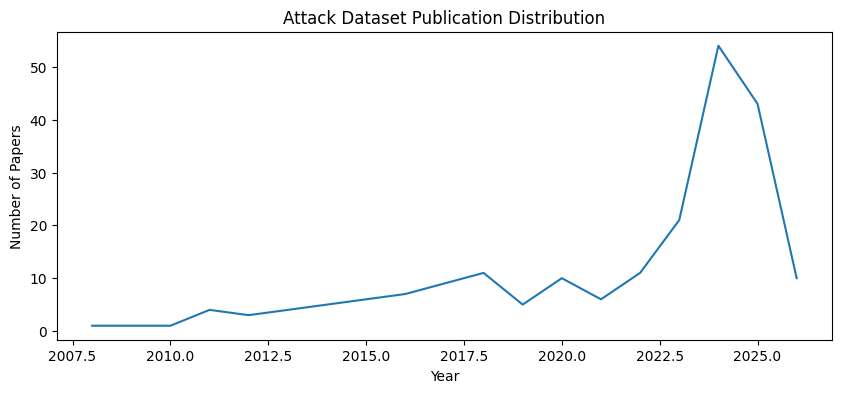

In [ ]:
# Distribusi Tahun

import matplotlib.pyplot as plt

year_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.plot(year_counts.index, year_counts.values)
plt.title("Attack Dataset Publication Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.show()

In [ ]:
# Text Preprocessing

!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        if token.is_stop == False and token.is_punct == False:
            if token.pos_ in ['NOUN','VERB','ADJ']:
                tokens.append(token.lemma_)
    return " ".join(tokens)

df['clean_text'] = df['Abstract'].apply(preprocess)

In [ ]:
# TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_df=0.9, min_df=5)
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])

print("TF-IDF shape:", tfidf_matrix.shape)

TF-IDF shape: (211, 873)


In [ ]:
# LDA Topic Modeling

from sklearn.decomposition import LatentDirichletAllocation

# n_topics = 5  # bisa kita tuning
# lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
# lda.fit(tfidf_matrix)

from sklearn.feature_extraction.text import CountVectorizer

# vectorizer = CountVectorizer(max_df=0.85, min_df=5)

custom_stopwords = ['system','security','propose','approach','study','model','paper']

vectorizer = CountVectorizer(
    max_df=0.85,
    min_df=5,
    stop_words='english'
)

# bisa extend stopwords manual nanti

count_matrix = vectorizer.fit_transform(df['clean_text'])

n_topics = 3

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(count_matrix)

LatentDirichletAllocation(n_components=3, random_state=42)

In [ ]:
# Top Words per Topic

feature_names = vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    print(f"\nTopic {idx+1}")
    print([feature_names[i] for i in topic.argsort()[-10:]])


Topic 1
['security', 'behavior', 'organization', 'propose', 'model', 'user', 'attack', 'information', 'detection', 'leakage']

Topic 2
['healthcare', 'access', 'computing', 'cybersecurity', 'attack', 'service', 'risk', 'breach', 'cloud', 'security']

Topic 3
['graph', 'attack', 'privacy', 'access', 'model', 'network', 'propose', 'base', 'breach', 'data']


In [ ]:
# Topic Coherence

!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.4 MB/s eta 0:00:00


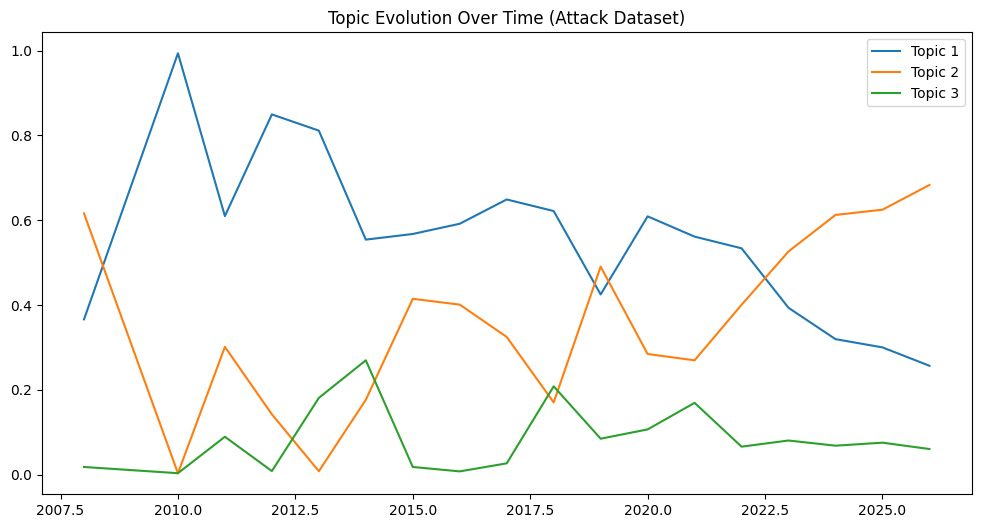

In [ ]:
topic_distribution = lda.transform(count_matrix)

df_topics = pd.DataFrame(topic_distribution)
df_topics['Year'] = df['Year'].values

year_topic = df_topics.groupby('Year').mean()

plt.figure(figsize=(12,6))
for i in range(lda.n_components):
    plt.plot(year_topic.index,
             year_topic[i],
             label=f"Topic {i+1}")

plt.legend()
plt.title("Topic Evolution Over Time (Attack Dataset)")
plt.show()

In [ ]:
# Attack Growth Rate (AGR)

from scipy.stats import linregress

for i in range(n_topics):
    slope, _, _, _, _ = linregress(year_topic.index, year_topic[i])
    print(f"Topic {i+1} Growth Rate:", slope)

Topic 1 Growth Rate: -0.023322513602246405
Topic 2 Growth Rate: 0.02175715106497388
Topic 3 Growth Rate: 0.0015653625372725234


In [ ]:
# BAGIAN MITIGASI

In [ ]:
# MITIGASI DATASET
pathMitigation = "/content/drive/MyDrive/Riset/Review/2738_attack_mitigation.csv"

# Scopus CSV
dfMitigation = pd.read_csv(pathMitigation, sep=",", encoding="utf-8")

print("Jumlah baris:", len(dfMitigation))
print("Kolom:", list(dfMitigation.columns))

# 3 baris paling awal
print("\n=== 3 Data Paling Awal ===")
print(dfMitigation.head(3))

# 3 baris paling akhir
print("\n=== 3 Data Paling Akhir ===")
print(dfMitigation.tail(3))

Jumlah baris: 2738
Kolom: ['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end', 'Cited by', 'DOI', 'Link', 'Abstract', 'Author Keywords', 'Index Keywords']

=== 3 Data Paling Awal ===
                                             Authors  \
0  Saeed, H.; Naseer, M.; Rasool, A.; Alsirhani, ...   
1                                            Liu, X.   
2       Zaferani, N.; Reza Afrash, M.R.; Moulaei, K.   

                                   Author full names  \
0  Saeed, Hasan Aftab (56367227500); Naseer, Mehw...   
1                             Liu, Xin (60336567300)   
2  Zaferani, Niloufar (60334216900); Reza Afrash,...   

                                        Author(s) ID  \
0  56367227500; 57214260796; 60335843100; 5741715...   
1                                        60336567300   
2              60334216900; 57204183233; 57200661149   

                                               Title  Ye

In [ ]:
# Keep only relevant columns
dfMitigation = dfMitigation[['Title', 'Year', 'Abstract']]

# Drop missing abstracts
dfMitigation = dfMitigation.dropna(subset=['Abstract'])

# Remove proceedings or generic entries
dfMitigation = dfMitigation[~dfMitigation['Title'].str.contains("Proceedings", case=False, na=False)]

# Remove very short abstracts
dfMitigation['word_count'] = dfMitigation['Abstract'].apply(lambda x: len(str(x).split()))
dfMitigation = dfMitigation[dfMitigation['word_count'] > 50]

print("Jumlah setelah cleaning:", len(dfMitigation))

Jumlah setelah cleaning: 2694


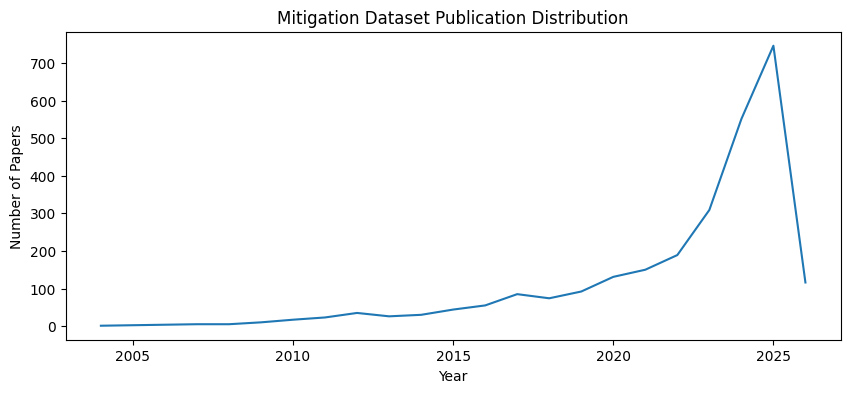

In [ ]:
# Distribusi Tahun

import matplotlib.pyplot as plt

year_counts_mit = dfMitigation['Year'].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.plot(year_counts_mit.index, year_counts_mit.values)
plt.title("Mitigation Dataset Publication Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.show()

In [ ]:
# Preprocessing

dfMitigation['clean_text'] = dfMitigation['Abstract'].apply(preprocess)

In [ ]:
# CountVectorizer

from sklearn.feature_extraction.text import CountVectorizer

vectorizer_mit = CountVectorizer(
    max_df=0.85,
    min_df=10,
    stop_words='english'
)

count_matrix_mit = vectorizer_mit.fit_transform(dfMitigation['clean_text'])

In [ ]:
# Jumlah Topic

n_topics_mit = 6

lda_mit = LatentDirichletAllocation(
    n_components=n_topics_mit,
    random_state=42
)

lda_mit.fit(count_matrix_mit)

LatentDirichletAllocation(n_components=6, random_state=42)

In [ ]:
# Top Words

feature_names_mit = vectorizer_mit.get_feature_names_out()

for idx, topic in enumerate(lda_mit.components_):
    print(f"\nTopic {idx+1}")
    print([feature_names_mit[i] for i in topic.argsort()[-10:]])


Topic 1
['challenge', 'cyber', 'healthcare', 'technology', 'breach', 'risk', 'cybersecurity', 'cloud', 'threat', 'security']

Topic 2
['sensitive', 'base', 'document', 'propose', 'detection', 'method', 'leakage', 'file', 'information', 'image']

Topic 3
['performance', 'machine', 'network', 'attack', 'feature', 'dataset', 'accuracy', 'learning', 'detection', 'model']

Topic 4
['paper', 'insider', 'leakage', 'organization', 'user', 'attack', 'data', 'security', 'breach', 'information']

Topic 5
['detect', 'propose', 'model', 'analysis', 'vulnerability', 'leakage', 'method', 'application', 'base', 'detection']

Topic 6
['leakage', 'device', 'model', 'base', 'security', 'detection', 'propose', 'privacy', 'attack', 'network']


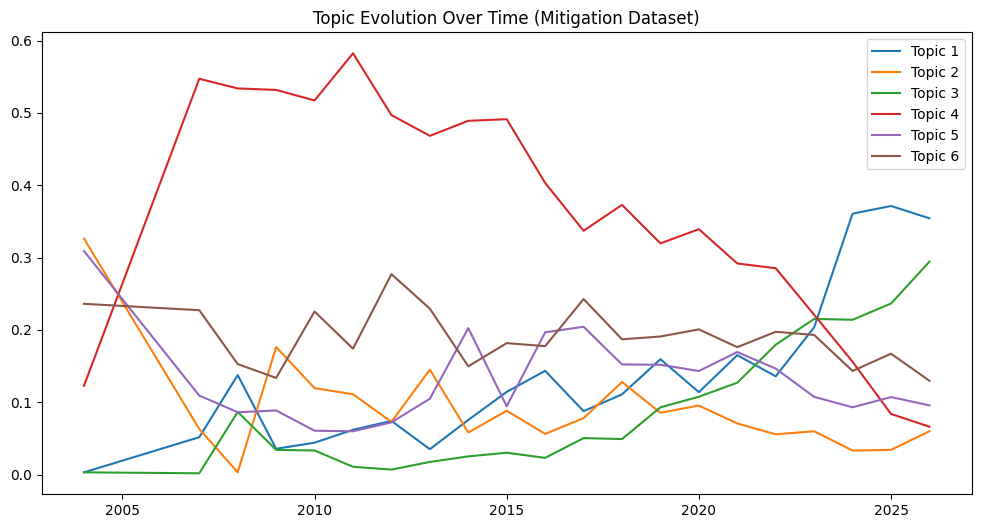

In [ ]:
# TOPIC COUNT

topic_distribution_mit = lda_mit.transform(count_matrix_mit)

df_topics_mit = pd.DataFrame(topic_distribution_mit)
df_topics_mit['Year'] = dfMitigation['Year'].values

year_topic_mit = df_topics_mit.groupby('Year').mean()

plt.figure(figsize=(12,6))
for i in range(lda_mit.n_components):
    plt.plot(year_topic_mit.index,
             year_topic_mit[i],
             label=f"Topic {i+1}")

plt.legend()
plt.title("Topic Evolution Over Time (Mitigation Dataset)")
plt.show()

In [ ]:
# GROWT RATE

from scipy.stats import linregress

for i in range(lda_mit.n_components):
    slope, _, _, _, _ = linregress(year_topic_mit.index,
                                   year_topic_mit[i])
    print(f"Mitigation Topic {i+1} Growth Rate:", slope)

Mitigation Topic 1 Growth Rate: 0.013832110333967293
Mitigation Topic 2 Growth Rate: -0.005542678056434306
Mitigation Topic 3 Growth Rate: 0.011841593473811368
Mitigation Topic 4 Growth Rate: -0.01690654771707336
Mitigation Topic 5 Growth Rate: -0.0010119260809185364
Mitigation Topic 6 Growth Rate: -0.002212551953352458
